In [2]:
pip install pandas numpy matplotlib scikit-learn mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 18.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
df=pd.DataFrame({"age": [39,50,38,53,28,37,49,52,31,42,37],
                "workclass":["State-gov", "Self-emp-not-inc", "Private", "Private", "Private", "Private", "Private", "Self-emp-not-inc", "Private", "Private", "Private"],
                "education": ["Bachelors", "Bachelors", "HS-grad", "11th", "Bachelors", "Masters", "9th", "HS-grad", "Masters", "Bachelors", "Some-college"],
                "gender": ["Male", "Male", "Male", "Male", "Female", "Female", "Female", "Male", "Female", "Male", "Male"],
                "hours-per-week": [40,13,40,40,40,40,16,45,50,40,80],
                "occupation": ["Adm-clerical", "Exec-managerial", "Handlers-cleaners", "Handlers-cleaners", "Prof-speciality", "Exec-managerial", "Other-service", "Exec-managerial", "Prof-speciality", "Exec-managerial", "Exec-managerial"],
                "income": ["<=50K", "<=50K", "<=50K", "<=50K", "<=50K", "<=50K", "<=50K", ">50K", ">50K", ">50K", ">50K"]})
df

,age,workclass,education,gender,hours-per-week,occupation,income
0,39,State-gov,Bachelors,Male,40,Adm-clerical,<=50K
1,50,Self-emp-not-inc,Bachelors,Male,13,Exec-managerial,<=50K
2,38,Private,HS-grad,Male,40,Handlers-cleaners,<=50K
3,53,Private,11th,Male,40,Handlers-cleaners,<=50K
4,28,Private,Bachelors,Female,40,Prof-speciality,<=50K
5,37,Private,Masters,Female,40,Exec-managerial,<=50K
6,49,Private,9th,Female,16,Other-service,<=50K
7,52,Self-emp-not-inc,HS-grad,Male,45,Exec-managerial,>50K
8,31,Private,Masters,Female,50,Prof-speciality,>50K
9,42,Private,Bachelors,Male,40,Exec-managerial,>50K


In [3]:
df.gender.value_counts()

gender
Male      7
Female    4
Name: count, dtype: int64

### One Hot Encoding

In [4]:
#Performing one hot encoding using pandas
import pandas as pd
print("Original features lists: ", list(df.columns))
df_dummies=pd.get_dummies(df)
print("Features after Dummy data: ", list(df_dummies.columns))

Original features lists:  ['age', 'workclass', 'education', 'gender', 'hours-per-week', 'occupation', 'income']
Features after Dummy data:  ['age', 'hours-per-week', 'workclass_Private', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'education_11th', 'education_9th', 'education_Bachelors', 'education_HS-grad', 'education_Masters', 'education_Some-college', 'gender_Female', 'gender_Male', 'occupation_Adm-clerical', 'occupation_Exec-managerial', 'occupation_Handlers-cleaners', 'occupation_Other-service', 'occupation_Prof-speciality', 'income_<=50K', 'income_>50K']


In [5]:
df_dummies

,age,hours-per-week,workclass_Private,workclass_Self-emp-not-inc,workclass_State-gov,education_11th,education_9th,education_Bachelors,education_HS-grad,education_Masters,education_Some-college,gender_Female,gender_Male,occupation_Adm-clerical,occupation_Exec-managerial,occupation_Handlers-cleaners,occupation_Other-service,occupation_Prof-speciality,income_<=50K,income_>50K
0,39,40,False,False,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False
1,50,13,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False
2,38,40,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False
3,53,40,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True,False
4,28,40,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False
5,37,40,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,True,False
6,49,16,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
7,52,45,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True
8,31,50,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True
9,42,40,True,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True


In [6]:
features=df_dummies.loc[:,"age":"occupation_Prof-speciality"]

X=features.values
y=df_dummies['income_>50K'].values
print(f'X shape: {X.shape}, y shape: {y.shape}')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=0)
lr=LogisticRegression().fit(X_train, y_train)

print("Training accuracy: ", lr.score(X_train, y_train))
print("Test accuracy: ", lr.score(X_test, y_test))

X shape: (11, 18), y shape: (11,)
Training accuracy:  1.0
Test accuracy:  0.6666666666666666


In [7]:
#Performing one hot encoding using sklearn
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

cat_cols= df.select_dtypes(include=['object']).columns.tolist() #to get categorical columns

encoder=OneHotEncoder(sparse_output=False)
one_hot_encoded=encoder.fit_transform(df[cat_cols])

#Getting them as dataframe
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cat_cols))
df_encoded=pd.concat([df, one_hot_df], axis=1)
df_encoded=df_encoded.drop(cat_cols, axis=1)

print("Encoded emp data: ", df_encoded)

#Training logistic regression on this data
# from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

features=df_encoded.loc[:,"age":"occupation_Prof-speciality"]
X=features.values
y=df_encoded['income_>50K'].values
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42)

lr2=DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

print("Training accuracy: ", lr2.score(X_train, y_train))
print("Test accuracy: ", lr2.score(X_test, y_test))

Encoded emp data:      age  hours-per-week  workclass_Private  workclass_Self-emp-not-inc  \
0    39              40                0.0                         0.0   
1    50              13                0.0                         1.0   
2    38              40                1.0                         0.0   
3    53              40                1.0                         0.0   
4    28              40                1.0                         0.0   
5    37              40                1.0                         0.0   
6    49              16                1.0                         0.0   
7    52              45                0.0                         1.0   
8    31              50                1.0                         0.0   
9    42              40                1.0                         0.0   
10   37              80                1.0                         0.0   

    workclass_State-gov  education_11th  education_9th  education_Bachelors  \
0            

### Binning

Bins:  [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]
Data points:  [[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
Bin membership for data points:  [[ 4]
 [10]
 [ 8]
 [ 6]
 [ 2]]
Encoded values:  [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
X binned shape:  (100, 10)


Text(0.5, 0, 'Input feature')

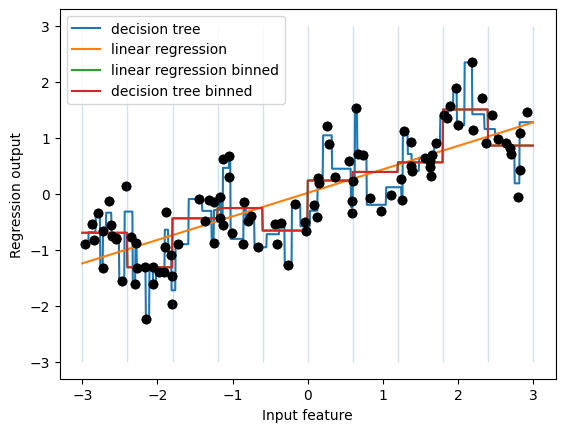

In [3]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import numpy as np
X, y = mglearn.datasets.make_wave(n_samples=100)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)
reg = DecisionTreeRegressor(min_samples_split=3).fit(X, y)
plt.plot(line, reg.predict(line), label="decision tree")
reg = LinearRegression().fit(X, y)
plt.plot(line, reg.predict(line), label="linear regression")
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input featur")

#Performing binning
import numpy as np
bins=np.linspace(-3,3,11)
print("Bins: ", bins)

which_bin=np.digitize(X, bins=bins) #np.digitize is used to record for each data point which bin it falls into. 
print("Data points: ", X[:5])
print("Bin membership for data points: ", which_bin[:5])

#Now perform one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False).fit(which_bin)
X_binned=encoder.transform(which_bin)
print("Encoded values: ",X_binned[:5])
print("X binned shape: ", X_binned.shape)

#plot
line_binned = encoder.transform(np.digitize(line, bins=bins))
reg = LinearRegression().fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='linear regression binned')
reg = DecisionTreeRegressor(min_samples_split=3).fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='decision tree binned')
plt.plot(X[:, 0], y, 'o', c='k')
plt.vlines(bins, -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")

### Interaction or Product features

(100, 20)


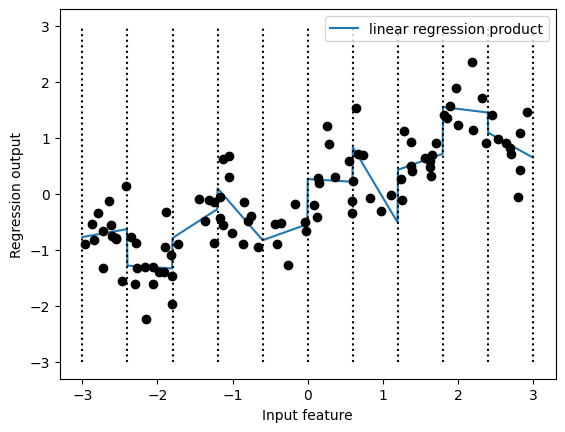

In [5]:
#All the data were taken from prev cell of binning
X_product=np.hstack([X_binned, X * X_binned])
print(X_product.shape)

reg=LinearRegression().fit(X_product, y)
line_product = np.hstack([line_binned, line * line_binned])
plt.plot(line, reg.predict(line_product), label='linear regression product')
for bin in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k')
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

### Polynomial Features

X_poly shape:  (100, 10)
Enteries of X:  [[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
Enteries of X_poly:  [[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]
Polynomial Feature names: 

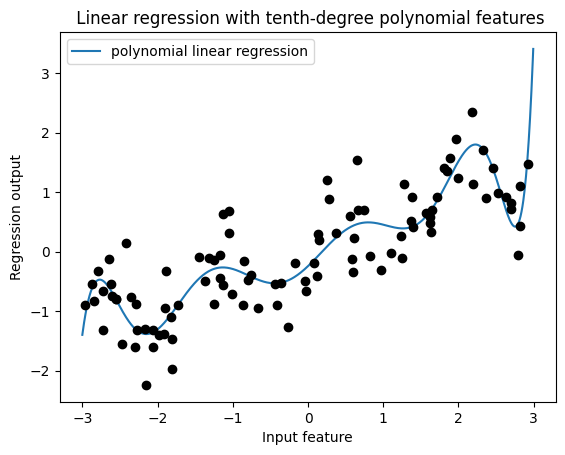

In [16]:
##All the data were taken from cell of binning
from sklearn.preprocessing import PolynomialFeatures
#include polynomials of x**10
#the default "include_bias=True" adds a feature that's constantly 1
poly=PolynomialFeatures(degree=10, include_bias=False)
X_poly=poly.fit_transform(X)
print("X_poly shape: ", X_poly.shape)
print("Enteries of X: ", X[:5])
print("Enteries of X_poly: ", X_poly[:5])
print("Polynomial Feature names: ", poly.get_feature_names_out())

#Plot
reg = LinearRegression().fit(X_poly, y)
line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label='polynomial linear regression')
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.title(" Linear regression with tenth-degree polynomial features")
plt.legend(loc="best")

## Univariate non linear transformation

In [36]:
#Applying log transformation on skewed data for regression model
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import skew
import pandas as pd
import numpy as np

data=fetch_california_housing()
X=pd.DataFrame(data.data, columns=data.feature_names)
y=pd.Series(data.target)

#Checking skewness
skew_value=X.skew()
print("X's columns", skew_value)

skew_y=y.skew()
print("y's value: ", skew_y)

#Finding the skewed data
skewed_cols=skew_value[skew_value > 1].index
print("Skewed cols: ", skewed_cols)

print('---------------------------------')
#Now tranform the skewed cols using log transformation
for col in skewed_cols:
    X[col] = np.log1p(X[col])

print("Columns after skewness:\n", X.skew())

#some data cols are still skewed
#Now training Linear Regression on new data X
print('-----------------------------------------')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr=LinearRegression().fit(X_train, y_train)
print("Result on skewed data")
print("Training accuracy: ", lr.score(X_train, y_train))
print("Test accuracy: ", lr.score(X_test, y_test))

X's columns MedInc         1.646657
HouseAge       0.060331
AveRooms      20.697869
AveBedrms     31.316956
Population     4.935858
AveOccup      97.639561
Latitude       0.465953
Longitude     -0.297801
dtype: float64
y's value:  0.9777632739098345
Skewed cols:  Index(['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup'], dtype='object')
---------------------------------
Columns after skewness:
 MedInc        0.226083
HouseAge      0.060331
AveRooms      1.390761
AveBedrms     8.988786
Population   -1.044087
AveOccup      3.879679
Latitude      0.465953
Longitude    -0.297801
dtype: float64
-----------------------------------------
Result on skewed data
Training accuracy:  0.6275791342002797
Test accuracy:  0.6231938625482222


# Automatic Feature Selection

## Univariate Statistics

In [39]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile
from sklearn.model_selection  import train_test_split

cancer=load_breast_cancer()

#Add noise to data
rng=np.random.RandomState(42)
noise=rng.normal(size=(len(cancer.data), 50))
X_w_noise = np.hstack([cancer.data, noise])

#Now split the data
X_train, X_test, y_train, y_test = train_test_split(X_w_noise, cancer.target, random_state=0, test_size=0.5)

#using f_classif (Deafult) for SelectPercentile
select=SelectPercentile(percentile=50).fit(X_train, y_train)

#transforming training set
X_train_selected=select.transform(X_train)

print("X_train.shape: ", X_train.shape)
print("X_train_selected.shape: ", X_train_selected.shape)
print("Selected features: ", select.get_support())

#Now train logistic regression
from sklearn.linear_model import LogisticRegression
X_test_selected=select.transform(X_test)
lr1=LogisticRegression().fit(X_train, y_train)
print("Score  with all features: ", lr1.score(X_test, y_test))

lr2=LogisticRegression().fit(X_train_selected, y_train)
print("Score with selected features: ", lr2.score(X_test_selected, y_test))

X_train.shape:  (284, 80)
X_train_selected.shape:  (284, 40)
Selected features:  [ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]
Score  with all features:  0.9192982456140351
Score with selected features:  0.9122807017543859


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

## Model Based Feature Selection

In [42]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets  import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data=load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

select=SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold='median')

select.fit(X_train, y_train)

X_train_l1=select.transform(X_train)

print("X_train.shape: ", X_train.shape)
print("X_train_l1.shape: ", X_train_l1.shape)

#Now train Logistic Regression model on selected features
X_test_l1=select.transform(X_test)

lr3=LogisticRegression().fit(X_train_l1, y_train)

print("Training accuracy: ", lr3.score(X_train_l1, y_train))
print("Test accuracy: ", lr3.score(X_test_l1, y_test))

X_train.shape:  (426, 30)
X_train_l1.shape:  (426, 15)
Training accuracy:  0.9507042253521126
Test accuracy:  0.965034965034965


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Iterative Feature Selection

In [44]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets  import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data=load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

select = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=40).fit(X_train, y_train)

X_train_rfe=select.transform(X_train)
X_test_rfe=select.transform(X_test)

#Train Logistic regression now
lr4=LogisticRegression().fit(X_train, y_train)
print("Test accuracy on X_train data: ", lr4.score(X_test, y_test))

lr5=LogisticRegression().fit(X_train_rfe, y_train)
print("Test accuracy on X_train_rfe data: ", lr5.score(X_test_rfe, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=40 > n_features=30. There will be no feature selection and all features will be kept.
  warnings.warn(


Test accuracy on X_train data:  0.965034965034965
Test accuracy on X_train_rfe data:  0.965034965034965


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c